# Training a ResNet50 CNN Model
**Authors:** Dickson Owuor, Raymond Cao

August 2025

## Main Goal

To train a CNN model from scratch to predict "good" and "bad" graphs. We are using a **PyTorch** training script.

In [1]:
# Installing Libraries (if not installed)
#!pip install torch torchvision

In [1]:
# Import Libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

### Choose the device and Hyperparameters

In [12]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
num_epochs = 25
batch_size = 16
learning_rate = 1e-4
img_size = 224  # ResNet50 input size

# Load dataset (all data in good/ and bad/)
dataset_dir = "../train_data/manual"

Using device: cpu


In [15]:
# The images are not similar to ImageNet, they are SEM images, then it is always advised to calculate the mean and std of the dataset and use them to normalize the images.
# Path to your dataset root (which has subfolders "good" and "bad")

# Temporary transform: only convert to tensor (no normalization yet)
temp_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),  # resize if needed
    transforms.ToTensor()
])

# Load dataset
dataset = datasets.ImageFolder(root=dataset_dir, transform=temp_transform)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)

# Compute mean and std
mean = 0.
std = 0.
nb_samples = 0.

for data, _ in loader:
    batch_samples = data.size(0)  # batch size (the last batch may be smaller!)
    data = data.view(batch_samples, data.size(1), -1)  # (B, C, H*W)
    mean += data.mean(2).sum(0)
    std += data.std(2).sum(0)
    nb_samples += batch_samples

mean /= nb_samples
std /= nb_samples


In [16]:
print(f"Mean: {mean.tolist()}")
print(f"Std: {std}")

Mean: [0.45290830731391907, 0.45292428135871887, 0.36621996760368347]
Std: tensor([0.2247, 0.2247, 0.1534])


In [23]:
# Data transformations
transform_pipe = transforms.Compose([
    transforms.Resize((img_size, img_size)),                # Resize the image to 224 x 224 as required by most vision models
    transforms.RandomHorizontalFlip(),                      # flip the image left-right with probability 0.5 (prevents model networks from overfitting)
    transforms.RandomRotation(10),                          # rotate the image by 10 degrees with probability 0.5 (helps model to recognize the same pattern even if the image is slightly rotated)
    transforms.ColorJitter(brightness=0.1, contrast=0.1),   # randomly adjust brightness, contrast and saturation of the image (without this augmentation model might memorize training data--overfits)
    transforms.ToTensor(),      # Converts PIL/Numpy/cv2 image of range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0] -- Model networks prefer floating point tensors
    transforms.Normalize(       # Ensures all pixels are within a similar scale
        mean=mean.tolist(),
        std=std.tolist()
    )
])

In [18]:

full_dataset = datasets.ImageFolder(dataset_dir, transform=transform_pipe)

In [25]:
# Train/Val split (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [48]:
# Models
networks = {
    "resnet50": models.resnet50(weights=None), # No Pretrained Weights
    "resnet50pretrained": models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1),
    "densenet121": models.densenet121(weights=None),
    "densenet121pretrained": models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1),
}

def get_fc_layer(num_features):
    fc_layer = torch.nn.Sequential(
        torch.nn.Linear(
            in_features=num_features,
            out_features=1                  # 1 class: 0-bad, 1-good
        ),
        torch.nn.Sigmoid()                  # Converts output to range [0, 1] (<0.5-bad, >0.5-good)
    )
    return fc_layer

for name, model in networks.items():
    print(f"{name}")

    if name.startswith("resnet50"):
        model.fc = get_fc_layer(model.fc.in_features)
    elif name.startswith("densenet121"):
        model.classifier = get_fc_layer(model.classifier.in_features)

    model = model.to(device)
#print(model)

resnet50
resnet50pretrained
densenet121
densenet121pretrained


In [49]:
# Choose model
model = networks["densenet121"]

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# Track performance
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Training loop
for epoch in range(num_epochs):
    model.train()
    train_loss, train_corrects = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        y = labels.view(-1, 1).float()

        optimizer.zero_grad()
        y_pred = model(inputs)
        pred_labels = (y_pred >= 0.5).float()
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)  # We need to multiply by batch size as loss is the mean loss of the samples in the batch
        train_corrects += torch.sum(pred_labels == y)

    train_loss /= len(train_dataset)
    train_acc = train_corrects / len(train_dataset)

    # Validation
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            y = labels.view(-1, 1).float()

            y_pred = model(inputs)
            pred_labels = (y_pred >= 0.5).float()
            loss = criterion(y_pred, y)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(pred_labels == y)

    val_loss /= len(val_dataset)
    val_acc = val_corrects / len(val_dataset)

    # Save epoch metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} -- "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch [1/25] Train Loss: 0.7033, Train Acc: 0.5100 -- Val Loss: 0.7260, Val Acc: 0.4231


### Plot Performance Results

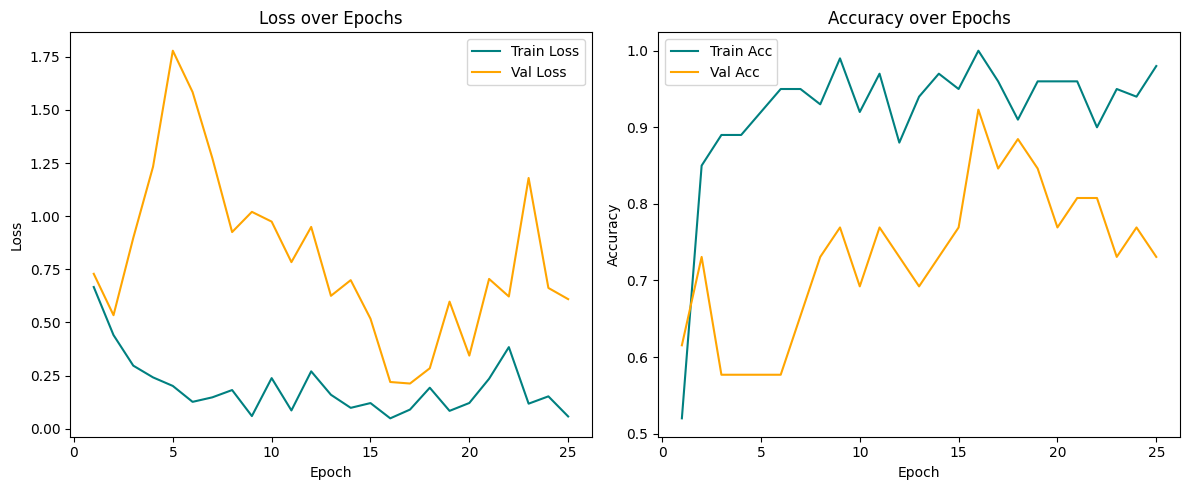

In [43]:
# ---- Plot results ----
epochs = range(1, num_epochs+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(epochs, train_losses, label="Train Loss", color="teal")
ax1.plot(epochs, val_losses, label="Val Loss", color="orange")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# Accuracy
ax2.plot(epochs, train_accuracies, label="Train Acc", color="teal")
ax2.plot(epochs, val_accuracies, label="Val Acc", color="orange")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
fig.savefig('performance_densenet.png', dpi=300)
plt.show()

In [42]:
# Save model
os.makedirs("../trained_models/checkpoints", exist_ok=True)
torch.save(model.state_dict(), "../trained_models/checkpoints/densenet121_sgt.pth")
print("Model saved.")

Model saved.


### Testing Model

In [23]:
# --- Load your trained model ---
# model = models.resnet50(weights=None)   # same definition as training
# model.fc = torch.nn.Sequential(
#     torch.nn.Linear(
#         in_features=model.fc.in_features,
#         out_features=1
#     ),
#     torch.nn.Sigmoid()
# )
#
# # Load the saved weights
# model.load_state_dict(torch.load("../trained_models/checkpoints/resnet50_sgt.pth", map_location="cpu"))
# model.load_state_dict(torch.load("../trained_models/checkpoints/resnet50_pretrained_sgt.pth", map_location="cpu"))
# model.eval()

In [50]:
# --- Image preprocessing ---
img_size = 224  # or whatever you used in training
test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())  # same as training
])

In [62]:
# --- Load your PNG image ---
img_path = "../train_data/auto/auto_images/4.tif__run00000__0885d862.png"
img_path = "../train_data/manual/good/ANF_good3.png"
#img_path = "../train_data/manual/bad/ANF_bad3.png"
image = Image.open(img_path).convert("RGB")
image = transform_pipe(image).unsqueeze(0)  # add batch dimension

# --- Inference ---
with torch.no_grad():
    y_pred = model(image)
    predicted_class = (y_pred >= 0.5).int()
    print(f"Predicted probabilities for {img_path}: {y_pred.item()}")

# --- Map prediction to label ---
class_names = ["bad", "good"]  # same order as your dataset class indices
pred_label = class_names[predicted_class.item()]

print(f"Predicted class for {img_path}: {pred_label}")

Predicted probabilities for ../train_data/manual/good/ANF_good3.png: 0.5590730309486389
Predicted class for ../train_data/manual/good/ANF_good3.png: good
